
# Notebook 1 — SVG Data Preprocessing + Tokenizer Training

Project: **SVG-GPT: Scaling Transformer Language Models for Vector Graphics**

This notebook prepares the dataset for the later model-training notebooks.

What this notebook does:

1. Mounts Google Drive and creates a reusable project folder.
2. Installs required libraries.
3. Downloads SVG datasets from HuggingFace.
4. Cleans and normalizes SVG strings.
5. Filters invalid, too-short, and too-long SVGs.
6. Validates SVGs using XML parsing.
7. Optionally checks rendering with CairoSVG.
8. Trains a BPE tokenizer on the cleaned SVG corpus.
9. Creates train/validation/test splits by SVG file.
10. Tokenizes the splits and saves reusable `.bin` files to Google Drive.
11. Saves useful statistics and plots for the final report.

Run this notebook from top to bottom in Google Colab.


In [1]:
# Check GPU availability.
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. This is okay for Notebook 1.")


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## 1. Mount Google Drive

All important files from **Notebook 1** will be saved inside a dedicated Google Drive folder for preprocessing.

Folder structure for Notebook 1:

```text
MyDrive/
  svg_gpt_scaling/
    notebook1_preprocessing/
      raw/
      cleaned/
      tokenizer/
      tokenized/
      stats/
      renders/
      plots/

```

In [2]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/svg_gpt_scaling")
PROJECT_DIR = PROJECT_ROOT / "notebook1_preprocessing"

RAW_DIR = PROJECT_DIR / "raw"
CLEANED_DIR = PROJECT_DIR / "cleaned"
TOKENIZER_DIR = PROJECT_DIR / "tokenizer"
TOKENIZED_DIR = PROJECT_DIR / "tokenized"
STATS_DIR = PROJECT_DIR / "stats"
RENDERS_DIR = PROJECT_DIR / "renders"
PLOTS_DIR = PROJECT_DIR / "plots"

for d in [
    RAW_DIR,
    CLEANED_DIR,
    TOKENIZER_DIR,
    TOKENIZED_DIR,
    STATS_DIR,
    RENDERS_DIR,
    PLOTS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Notebook 1 folder:", PROJECT_DIR)
print("Folders ready.")

Project root: /content/drive/MyDrive/svg_gpt_scaling
Notebook 1 folder: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing
Folders ready.



## 2. Install Dependencies

This notebook uses:

- `datasets` to load HuggingFace datasets
- `tokenizers` to train a BPE tokenizer
- `lxml` to validate XML/SVG syntax
- `cairosvg` to test rendering SVGs into PNGs
- `pandas`, `numpy`, `matplotlib`, and `tqdm` for analysis and progress bars


In [4]:

!pip -q install datasets tokenizers sentencepiece lxml cairosvg tqdm pandas matplotlib numpy


In [5]:

import os
import re
import json
import math
import time
import random
import hashlib
import html
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset, concatenate_datasets
from lxml import etree

print("Imports complete.")


Imports complete.



## 3. Configuration

For the project,  at least **100M training tokens** are required.

However, preprocessing everything can take time. So this notebook has two modes:

- `QUICK_TEST_MODE = True`: process a small subset first, useful for debugging.
- `QUICK_TEST_MODE = False`: process the full dataset for actual project results.

Start with `QUICK_TEST_MODE = True` once. If everything works, switch it to `False` and rerun.


In [6]:

# Main settings

QUICK_TEST_MODE = False

RANDOM_SEED = 42

# Primary dataset required by the project PDF.
PRIMARY_DATASET = "starvector/svg-icons-simple"

# Optional supplementary datasets.
# if the token count is below 100M, we can enable one or more supplementary datasets.
USE_EMOJI_DATASET = True
USE_FONTS_DATASET = False
USE_STACK_DATASET = False
USE_SVGEN_500K = True

SUPPLEMENTARY_DATASETS = {
    "emoji": "starvector/svg-emoji-simple",
    "fonts": "starvector/svg-fonts-simple",
    "stack": "starvector/svg-stack-simple",
    "svgen_500k": "umuthopeyildirim/svgen-500k",
}

# Filtering settings
MIN_CHARS = 50
MAX_CHARS = 20000

# This is a pre-tokenizer rough limit using characters.
# The exact token threshold is applied after tokenizer training.
# SVGs much longer than this may be slow and unnecessary for small context windows.
MAX_APPROX_CHARS_BEFORE_TOKENIZER = 12000

# Tokenizer settings
VOCAB_SIZE = 4096
MIN_FREQUENCY = 2


# Here we filter encoded SVGs above this token length.
MAX_TOKENS_PER_SVG = 2048

# Split ratios by file, not by tokens.
TRAIN_RATIO = 0.98
VAL_RATIO = 0.01
TEST_RATIO = 0.01


TARGET_TRAIN_TOKENS = 100_000_000

if QUICK_TEST_MODE:
    # Keep this small for first run.
    MAX_EXAMPLES_PER_DATASET = 5000
else:
    MAX_EXAMPLES_PER_DATASET = None

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("QUICK_TEST_MODE:", QUICK_TEST_MODE)
print("Primary dataset:", PRIMARY_DATASET)
print("Vocabulary size:", VOCAB_SIZE)
print("Max tokens per SVG:", MAX_TOKENS_PER_SVG)


QUICK_TEST_MODE: False
Primary dataset: starvector/svg-icons-simple
Vocabulary size: 4096
Max tokens per SVG: 2048



## 4. Helper Functions

These functions will:

- Detect which column contains the SVG text.
- Clean SVG code.
- Validate XML.
- Render-check SVGs.
- Save and load JSONL files.


In [7]:

def detect_svg_column(dataset) -> str:
    """
    Detect the column containing SVG code.

    Different HuggingFace SVG datasets may use slightly different column names.
    This function tries common names first, then falls back to scanning examples.
    """
    common_names = ["svg", "Svg", "SVG", "code", "text", "content", "image", "xml"]
    columns = list(dataset.column_names)

    for name in common_names:
        if name in columns:
            return name

    # Fallback: inspect the first few rows.
    sample_count = min(20, len(dataset))
    for col in columns:
        for i in range(sample_count):
            value = dataset[i][col]
            if isinstance(value, str) and "<svg" in value.lower():
                return col

    raise ValueError(f"Could not detect SVG column. Available columns: {columns}")


def strip_svg_comments(svg: str) -> str:
    return re.sub(r"<!--.*?-->", "", svg, flags=re.DOTALL)


def remove_metadata_blocks(svg: str) -> str:
    """
    Remove metadata-like blocks that are not essential for simple icon rendering.
    This keeps the SVG more focused on geometry and styling.
    """
    svg = re.sub(r"<metadata.*?</metadata>", "", svg, flags=re.DOTALL | re.IGNORECASE)
    svg = re.sub(r"<title.*?</title>", "", svg, flags=re.DOTALL | re.IGNORECASE)
    svg = re.sub(r"<desc.*?</desc>", "", svg, flags=re.DOTALL | re.IGNORECASE)
    return svg


def normalize_whitespace(svg: str) -> str:
    svg = svg.replace("\n", " ").replace("\t", " ").replace("\r", " ")
    svg = re.sub(r"\s+", " ", svg)
    svg = re.sub(r">\s+<", "><", svg)
    return svg.strip()


def round_numeric_precision(svg: str, decimals: int = 1) -> str:
    """
    Round decimal numbers to reduce tokenizer vocabulary noise.

    Example:
    12.3456 -> 12.3
    -7.891 -> -7.9
    """
    pattern = re.compile(r"(?<![A-Za-z])[-+]?\d*\.\d+")

    def repl(match):
        value = float(match.group(0))
        rounded = round(value, decimals)
        if rounded == int(rounded):
            return str(int(rounded))
        return f"{rounded:.{decimals}f}".rstrip("0").rstrip(".")

    return pattern.sub(repl, svg)


def clean_svg(svg: str) -> str:
    """
    Full cleaning pipeline for one SVG string.
    """
    if svg is None:
        return ""

    svg = str(svg)
    svg = html.unescape(svg)
    svg = svg.strip()

    # Keep only the substring starting at <svg if there is extra text before it.
    start = svg.lower().find("<svg")
    if start >= 0:
        svg = svg[start:]

    svg = strip_svg_comments(svg)
    svg = remove_metadata_blocks(svg)
    svg = round_numeric_precision(svg, decimals=1)
    svg = normalize_whitespace(svg)

    return svg


def is_valid_xml(svg: str) -> bool:
    """
    Check whether the SVG is valid XML.
    """
    try:
        etree.fromstring(svg.encode("utf-8"))
        return True
    except Exception:
        return False


def has_svg_root(svg: str) -> bool:
    """
    Check whether the XML root element is SVG.
    """
    try:
        root = etree.fromstring(svg.encode("utf-8"))
        tag = root.tag
        if isinstance(tag, str):
            return tag.lower().endswith("svg")
        return False
    except Exception:
        return False


def svg_hash(svg: str) -> str:
    return hashlib.md5(svg.encode("utf-8")).hexdigest()


def save_jsonl(records: List[Dict], path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")


def load_jsonl(path: Path) -> List[Dict]:
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records


print("Helper functions ready.")


Helper functions ready.



## 5. Load HuggingFace SVG Dataset(s)

The primary dataset is:

```python
starvector/svg-icons-simple
```

This notebook is written to be robust because dataset column names can vary.


In [8]:

from datasets import Dataset

def load_one_svg_dataset(dataset_name: str, max_examples: Optional[int] = None):
    print(f"Loading dataset: {dataset_name}")

    ds = load_dataset(dataset_name)

    # Use train split if available; otherwise use the first split.
    if isinstance(ds, dict):
        split_name = "train" if "train" in ds else list(ds.keys())[0]
        ds = ds[split_name]

    if max_examples is not None:
        max_examples = min(max_examples, len(ds))
        ds = ds.select(range(max_examples))

    svg_col = detect_svg_column(ds)
    print(f"Loaded {len(ds):,} rows from {dataset_name}. SVG column: {svg_col}")

    return ds, svg_col


datasets_to_load = [PRIMARY_DATASET]

if USE_EMOJI_DATASET:
    datasets_to_load.append(SUPPLEMENTARY_DATASETS["emoji"])
if USE_FONTS_DATASET:
    datasets_to_load.append(SUPPLEMENTARY_DATASETS["fonts"])
if USE_STACK_DATASET:
    datasets_to_load.append(SUPPLEMENTARY_DATASETS["stack"])
if USE_SVGEN_500K:
    datasets_to_load.append(SUPPLEMENTARY_DATASETS["svgen_500k"])

loaded_sources = []

for name in datasets_to_load:
    ds, svg_col = load_one_svg_dataset(name, MAX_EXAMPLES_PER_DATASET)
    loaded_sources.append((name, ds, svg_col))

print("\nDatasets loaded:")
for name, ds, svg_col in loaded_sources:
    print("-", name, len(ds), "rows", "svg_col =", svg_col)


Loading dataset: starvector/svg-icons-simple


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded 80,434 rows from starvector/svg-icons-simple. SVG column: Svg
Loading dataset: starvector/svg-emoji-simple


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/12.7M [00:00<?, ?B/s]

...

Loaded 4,114 rows from starvector/svg-emoji-simple. SVG column: Svg
Loading dataset: umuthopeyildirim/svgen-500k


README.md: 0.00B [00:00, ?B/s]

data/main.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/216509 [00:00<?, ? examples/s]

Loaded 216,509 rows from umuthopeyildirim/svgen-500k. SVG column: output

Datasets loaded:
- starvector/svg-icons-simple 80434 rows svg_col = Svg
- starvector/svg-emoji-simple 4114 rows svg_col = Svg
- umuthopeyildirim/svgen-500k 216509 rows svg_col = output



## 6. Clean, Filter, Validate, and Deduplicate SVGs

This step may take time on the full dataset.

The output is saved to:

```text
cleaned/cleaned_svgs.jsonl
```

If that file already exists, the notebook can reuse it.


In [9]:

cleaned_path = CLEANED_DIR / ("cleaned_svgs_quick.jsonl" if QUICK_TEST_MODE else "cleaned_svgs_full.jsonl")

REUSE_CLEANED_IF_EXISTS = True

if REUSE_CLEANED_IF_EXISTS and cleaned_path.exists():
    print("Found existing cleaned file. Loading:", cleaned_path)
    cleaned_records = load_jsonl(cleaned_path)
else:
    print("Cleaning SVGs from scratch...")

    cleaned_records = []
    seen_hashes = set()

    raw_count = 0
    too_short_count = 0
    too_long_count = 0
    invalid_xml_count = 0
    non_svg_root_count = 0
    duplicate_count = 0

    for source_name, ds, svg_col in loaded_sources:
        for row in tqdm(ds, desc=f"Cleaning {source_name}"):
            raw_count += 1
            raw_svg = row[svg_col]
            cleaned = clean_svg(raw_svg)

            if len(cleaned) < MIN_CHARS:
                too_short_count += 1
                continue

            if len(cleaned) > MAX_APPROX_CHARS_BEFORE_TOKENIZER:
                too_long_count += 1
                continue

            if not is_valid_xml(cleaned):
                invalid_xml_count += 1
                continue

            if not has_svg_root(cleaned):
                non_svg_root_count += 1
                continue

            h = svg_hash(cleaned)
            if h in seen_hashes:
                duplicate_count += 1
                continue
            seen_hashes.add(h)

            cleaned_records.append({
                "source": source_name,
                "svg": cleaned,
                "char_len": len(cleaned),
                "hash": h,
            })

    save_jsonl(cleaned_records, cleaned_path)

    print("\nCleaning summary")
    print("Raw examples:", raw_count)
    print("Kept:", len(cleaned_records))
    print("Too short:", too_short_count)
    print("Too long:", too_long_count)
    print("Invalid XML:", invalid_xml_count)
    print("Non-SVG root:", non_svg_root_count)
    print("Duplicates:", duplicate_count)
    print("Saved:", cleaned_path)

print("Total cleaned SVGs:", len(cleaned_records))
print("Example:")
print(cleaned_records[0]["svg"][:500])


Cleaning SVGs from scratch...


Cleaning starvector/svg-icons-simple:   0%|          | 0/80434 [00:00<?, ?it/s]

Cleaning starvector/svg-emoji-simple:   0%|          | 0/4114 [00:00<?, ?it/s]

Cleaning umuthopeyildirim/svgen-500k:   0%|          | 0/216509 [00:00<?, ?it/s]


Cleaning summary
Raw examples: 301057
Kept: 285731
Too short: 74
Too long: 2705
Invalid XML: 1916
Non-SVG root: 0
Duplicates: 10631
Saved: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/cleaned/cleaned_svgs_full.jsonl
Total cleaned SVGs: 285731
Example:
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black" stroke-width="0.3" stroke-opacity="1" filling="0" d="M10.1 7.3 L10.1 7.3 C11 7.4 14.6 7.6 14.4 9.4 C14.2 11.2 10.6 11.3 9.5 11.2 C80.6 11.2 4.8 10.6 5.7 8.7 C60.3 7.5 9 7.4 10.1 7.3 L10.1 7.3"></path><path fill="none" stroke="black" stroke-width="0.3" stroke-opacity="1" filling="0" d="M10.1 9.2 L10.1 9.2 C10.7 9.3 14.3 10.2 11.5 11.1 C11 11.3 9 11.2 8.3 10.9 C70.4 10.5 7.3 10



## 7. Basic Dataset Statistics Before Tokenization

These statistics are useful for the final report.


In [10]:

df_clean = pd.DataFrame(cleaned_records)

display(df_clean.head())

print("Number of cleaned SVGs:", len(df_clean))
print("\nCharacter length statistics:")
display(df_clean["char_len"].describe())

source_counts = df_clean["source"].value_counts()
print("\nSource counts:")
display(source_counts)

stats_before_tokenizer_path = STATS_DIR / ("clean_stats_quick.csv" if QUICK_TEST_MODE else "clean_stats_full.csv")
df_clean.to_csv(stats_before_tokenizer_path, index=False)
print("Saved CSV:", stats_before_tokenizer_path)


,source,svg,char_len,hash
0,starvector/svg-icons-simple,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo...",928,93ac46885d4bff076a92b63dfac7efea
1,starvector/svg-icons-simple,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo...",1610,91014ab7489b29252c9d65a6240e4dee
2,starvector/svg-icons-simple,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo...",2142,27d907817998f336e02fb12568bc8608
3,starvector/svg-icons-simple,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo...",3086,87524ae3f032e15ca1df28ed942cd5b6
4,starvector/svg-icons-simple,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo...",1605,6ac42367689afe717bb599a059c467b0


Number of cleaned SVGs: 285731

Character length statistics:


,char_len
count,285731.000000
mean,1501.144111
std,1475.828570
min,122.000000
25%,575.000000
50%,978.000000
75%,1852.000000
max,11999.000000



Source counts:


,count
source,
umuthopeyildirim/svgen-500k,203122
starvector/svg-icons-simple,80434
starvector/svg-emoji-simple,2175


Saved CSV: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/stats/clean_stats_full.csv


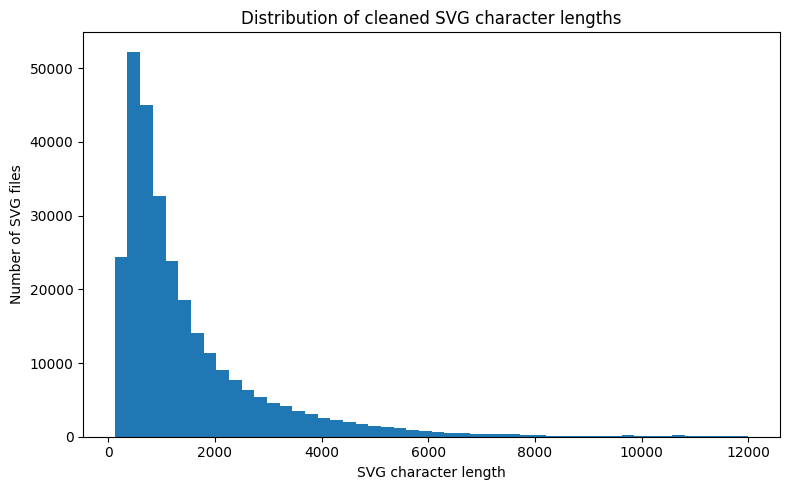

Saved plot: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/plots/char_length_hist_full.png


In [11]:

plt.figure(figsize=(8, 5))
plt.hist(df_clean["char_len"], bins=50)
plt.xlabel("SVG character length")
plt.ylabel("Number of SVG files")
plt.title("Distribution of cleaned SVG character lengths")
plt.tight_layout()

char_len_plot_path = PLOTS_DIR / ("char_length_hist_quick.png" if QUICK_TEST_MODE else "char_length_hist_full.png")
plt.savefig(char_len_plot_path, dpi=200)
plt.show()

print("Saved plot:", char_len_plot_path)



## 8. Render a Few Cleaned SVG Examples

This helps you visually inspect the data and gives examples for the final report.

If rendering fails because of environment issues, the XML validation above is still the main required check.


Example 1: char_len=380, render_ok=True


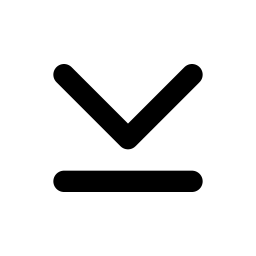

Example 2: char_len=978, render_ok=True


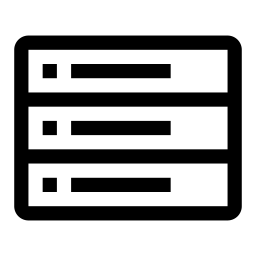

Example 3: char_len=3322, render_ok=True


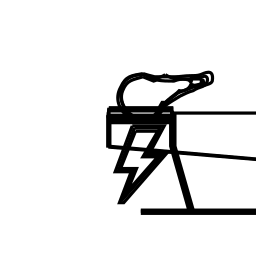

Saved rendered example metadata: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/stats/rendered_examples_full.json


In [12]:

import cairosvg
from IPython.display import display, Image

def render_svg_to_png(svg: str, output_path: Path, output_width: int = 256, output_height: int = 256) -> bool:
    try:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        cairosvg.svg2png(
            bytestring=svg.encode("utf-8"),
            write_to=str(output_path),
            output_width=output_width,
            output_height=output_height,
        )
        return True
    except Exception as e:
        return False


sample_render_dir = RENDERS_DIR / ("clean_examples_quick" if QUICK_TEST_MODE else "clean_examples_full")
sample_render_dir.mkdir(parents=True, exist_ok=True)

# Pick examples from low, medium, and high complexity based on character length.
df_sorted = df_clean.sort_values("char_len").reset_index(drop=True)
indices = [
    int(len(df_sorted) * 0.10),
    int(len(df_sorted) * 0.50),
    int(len(df_sorted) * 0.90),
]

rendered_examples = []

for rank, idx in enumerate(indices, start=1):
    record = df_sorted.iloc[idx].to_dict()
    png_path = sample_render_dir / f"example_{rank}_charlen_{record['char_len']}.png"
    ok = render_svg_to_png(record["svg"], png_path)
    rendered_examples.append({
        "rank": rank,
        "char_len": record["char_len"],
        "render_ok": ok,
        "png_path": str(png_path),
        "svg": record["svg"],
    })
    print(f"Example {rank}: char_len={record['char_len']}, render_ok={ok}")
    if ok:
        display(Image(filename=str(png_path)))

rendered_examples_path = STATS_DIR / ("rendered_examples_quick.json" if QUICK_TEST_MODE else "rendered_examples_full.json")
with rendered_examples_path.open("w", encoding="utf-8") as f:
    json.dump(rendered_examples, f, indent=2)

print("Saved rendered example metadata:", rendered_examples_path)



## 9. Train a BPE Tokenizer

The project asks us to train a tokenizer on the SVG corpus.

We will train a BPE tokenizer with:

- Vocabulary size: `4096`
- Special tokens:
  - `<pad>`
  - `<bos>`
  - `<eos>`
  - `<unk>`

The tokenizer will be saved to Google Drive so later notebooks can reuse it.


In [13]:

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.processors import TemplateProcessing

tokenizer_path = TOKENIZER_DIR / f"svg_bpe_vocab{VOCAB_SIZE}.json"
tokenizer_training_text_path = CLEANED_DIR / ("tokenizer_training_text_quick.txt" if QUICK_TEST_MODE else "tokenizer_training_text_full.txt")

REUSE_TOKENIZER_IF_EXISTS = False

# Write training text file if needed.
if not tokenizer_training_text_path.exists():
    print("Writing tokenizer training text file...")
    with tokenizer_training_text_path.open("w", encoding="utf-8") as f:
        for rec in tqdm(cleaned_records):
            f.write(rec["svg"] + "\n")
    print("Saved:", tokenizer_training_text_path)
else:
    print("Tokenizer training text file already exists:", tokenizer_training_text_path)

if REUSE_TOKENIZER_IF_EXISTS and tokenizer_path.exists():
    print("Loading existing tokenizer:", tokenizer_path)
    tokenizer = Tokenizer.from_file(str(tokenizer_path))
else:
    print("Training new BPE tokenizer...")

    tokenizer = Tokenizer(BPE(unk_token="<unk>"))
    tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
    tokenizer.decoder = ByteLevelDecoder()

    trainer = BpeTrainer(
        vocab_size=VOCAB_SIZE,
        min_frequency=MIN_FREQUENCY,
        special_tokens=["<pad>", "<bos>", "<eos>", "<unk>"],
        show_progress=True,
    )

    tokenizer.train([str(tokenizer_training_text_path)], trainer=trainer)

    tokenizer.post_processor = TemplateProcessing(
        single="<bos> $A <eos>",
        special_tokens=[
            ("<bos>", tokenizer.token_to_id("<bos>")),
            ("<eos>", tokenizer.token_to_id("<eos>")),
        ],
    )

    tokenizer.save(str(tokenizer_path))
    print("Saved tokenizer:", tokenizer_path)

print("Tokenizer vocab size:", tokenizer.get_vocab_size())
print("Special token ids:")
for tok in ["<pad>", "<bos>", "<eos>", "<unk>"]:
    print(tok, "->", tokenizer.token_to_id(tok))

example_svg = cleaned_records[0]["svg"]
enc = tokenizer.encode(example_svg)
print("\nExample token count:", len(enc.ids))
print("First 30 token ids:", enc.ids[:30])
print("Decoded preview:")
print(tokenizer.decode(enc.ids[:80])[:500])


Writing tokenizer training text file...


  0%|          | 0/285731 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/cleaned/tokenizer_training_text_full.txt
Training new BPE tokenizer...
Saved tokenizer: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/tokenizer/svg_bpe_vocab4096.json
Tokenizer vocab size: 4096
Special token ids:
<pad> -> 0
<bos> -> 1
<eos> -> 2
<unk> -> 3

Example token count: 464
First 30 token ids: [1, 30, 230, 276, 174, 274, 275, 281, 16, 88, 21, 16, 277, 17, 294, 17, 230, 5, 299, 174, 18, 192, 267, 267, 5, 288, 174, 261, 251, 5]
Decoded preview:
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black" stroke-width="0.3" stroke-opacity="1" filling="0" d="M10.1 7.3 L10.1 7.3 C11



## 10. Compute Token Lengths and Filter by Token Threshold

The project suggests filtering SVGs above a maximum token length such as 1024 or 2048.

Here we use:

```python
MAX_TOKENS_PER_SVG = 2048
```

This keeps later Transformer training manageable.


In [14]:

token_len_cache_path = STATS_DIR / ("token_lengths_quick.csv" if QUICK_TEST_MODE else "token_lengths_full.csv")

REUSE_TOKEN_LENGTHS_IF_EXISTS = True

if REUSE_TOKEN_LENGTHS_IF_EXISTS and token_len_cache_path.exists():
    print("Loading cached token lengths:", token_len_cache_path)
    df_tokens = pd.read_csv(token_len_cache_path)
else:
    print("Encoding SVGs to compute token lengths...")
    rows = []
    for rec in tqdm(cleaned_records):
        ids = tokenizer.encode(rec["svg"]).ids
        rows.append({
            "source": rec["source"],
            "hash": rec["hash"],
            "char_len": rec["char_len"],
            "token_len": len(ids),
        })

    df_tokens = pd.DataFrame(rows)
    df_tokens.to_csv(token_len_cache_path, index=False)
    print("Saved token length CSV:", token_len_cache_path)

display(df_tokens.head())
print("Token length statistics:")
display(df_tokens["token_len"].describe())

keep_hashes = set(df_tokens.loc[df_tokens["token_len"] <= MAX_TOKENS_PER_SVG, "hash"])
filtered_records = [rec for rec in cleaned_records if rec["hash"] in keep_hashes]

print("Before token-length filtering:", len(cleaned_records))
print("After token-length filtering:", len(filtered_records))
print("Removed:", len(cleaned_records) - len(filtered_records))


Encoding SVGs to compute token lengths...


  0%|          | 0/285731 [00:00<?, ?it/s]

Saved token length CSV: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/stats/token_lengths_full.csv


,source,hash,char_len,token_len
0,starvector/svg-icons-simple,93ac46885d4bff076a92b63dfac7efea,928,464
1,starvector/svg-icons-simple,91014ab7489b29252c9d65a6240e4dee,1610,884
2,starvector/svg-icons-simple,27d907817998f336e02fb12568bc8608,2142,1107
3,starvector/svg-icons-simple,87524ae3f032e15ca1df28ed942cd5b6,3086,1633
4,starvector/svg-icons-simple,6ac42367689afe717bb599a059c467b0,1605,876


Token length statistics:


,token_len
count,285731.000000
mean,874.111678
std,947.962460
min,50.000000
25%,308.000000
50%,553.000000
75%,1071.000000
max,10648.000000


Before token-length filtering: 285731
After token-length filtering: 260381
Removed: 25350


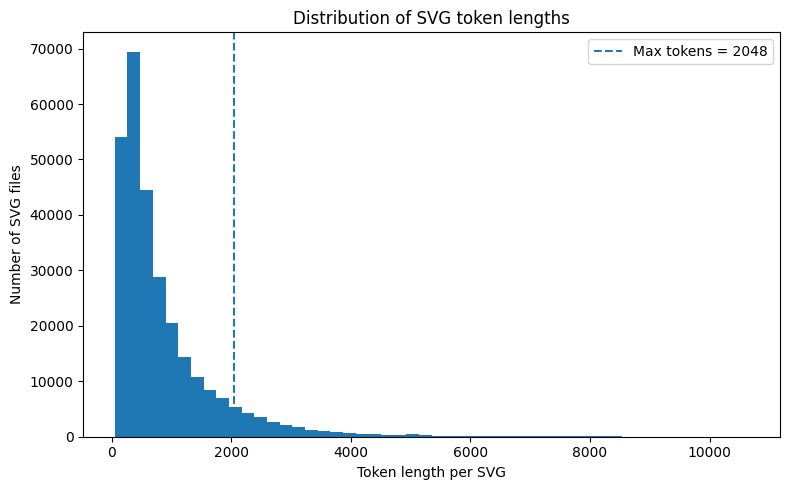

Saved plot: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/plots/token_length_hist_full.png


In [15]:

plt.figure(figsize=(8, 5))
plt.hist(df_tokens["token_len"], bins=50)
plt.axvline(MAX_TOKENS_PER_SVG, linestyle="--", label=f"Max tokens = {MAX_TOKENS_PER_SVG}")
plt.xlabel("Token length per SVG")
plt.ylabel("Number of SVG files")
plt.title("Distribution of SVG token lengths")
plt.legend()
plt.tight_layout()

token_len_plot_path = PLOTS_DIR / ("token_length_hist_quick.png" if QUICK_TEST_MODE else "token_length_hist_full.png")
plt.savefig(token_len_plot_path, dpi=200)
plt.show()

print("Saved plot:", token_len_plot_path)



## 11. Create Train / Validation / Test Splits by SVG File

The project recommends:

- Train: 98%
- Validation: 1%
- Test: 1%

Important: We split by SVG file, not by token position, to avoid leakage.


In [16]:

split_records_path = CLEANED_DIR / ("split_records_quick.json" if QUICK_TEST_MODE else "split_records_full.json")

REUSE_SPLITS_IF_EXISTS = True

if REUSE_SPLITS_IF_EXISTS and split_records_path.exists():
    print("Loading existing splits:", split_records_path)
    with split_records_path.open("r", encoding="utf-8") as f:
        split_records = json.load(f)
else:
    records = filtered_records.copy()
    random.Random(RANDOM_SEED).shuffle(records)

    n = len(records)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    n_test = n - n_train - n_val

    split_records = {
        "train": records[:n_train],
        "val": records[n_train:n_train+n_val],
        "test": records[n_train+n_val:],
    }

    with split_records_path.open("w", encoding="utf-8") as f:
        json.dump(split_records, f)

    print("Saved splits:", split_records_path)

for split_name, records in split_records.items():
    print(split_name, "files:", len(records))


Saved splits: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/cleaned/split_records_full.json
train files: 255173
val files: 2603
test files: 2605



## 12. Tokenize Splits and Save `.bin` Files

Later training notebooks can directly memory-map these files.

Each SVG is encoded as:

```text
<bos> SVG tokens <eos>
```

Then all SVGs in a split are concatenated into one long token stream.

Because the vocabulary size is below 65,535, we save token ids as `uint16` to reduce disk size.


In [17]:

def encode_records_to_bin(records: List[Dict], split_name: str):
    token_bin_path = TOKENIZED_DIR / f"{split_name}_vocab{VOCAB_SIZE}_{'quick' if QUICK_TEST_MODE else 'full'}.bin"
    lengths_path = TOKENIZED_DIR / f"{split_name}_lengths_vocab{VOCAB_SIZE}_{'quick' if QUICK_TEST_MODE else 'full'}.npy"

    if token_bin_path.exists() and lengths_path.exists():
        print(f"Reusing existing {split_name} token files:")
        print(" ", token_bin_path)
        print(" ", lengths_path)

        token_count = token_bin_path.stat().st_size // np.dtype(np.uint16).itemsize
        lengths = np.load(lengths_path)
        return {
            "split": split_name,
            "files": len(records),
            "tokens": int(token_count),
            "bin_path": str(token_bin_path),
            "lengths_path": str(lengths_path),
            "avg_tokens_per_file": float(np.mean(lengths)) if len(lengths) else 0.0,
        }

    print(f"Encoding {split_name} split...")

    all_ids = []
    lengths = []

    for rec in tqdm(records, desc=f"Tokenizing {split_name}"):
        ids = tokenizer.encode(rec["svg"]).ids
        if len(ids) <= MAX_TOKENS_PER_SVG:
            all_ids.extend(ids)
            lengths.append(len(ids))

    arr = np.array(all_ids, dtype=np.uint16)
    arr.tofile(token_bin_path)

    lengths_arr = np.array(lengths, dtype=np.int32)
    np.save(lengths_path, lengths_arr)

    return {
        "split": split_name,
        "files": len(lengths),
        "tokens": int(len(arr)),
        "bin_path": str(token_bin_path),
        "lengths_path": str(lengths_path),
        "avg_tokens_per_file": float(np.mean(lengths_arr)) if len(lengths_arr) else 0.0,
    }


split_summaries = []
for split_name in ["train", "val", "test"]:
    summary = encode_records_to_bin(split_records[split_name], split_name)
    split_summaries.append(summary)

df_split_summary = pd.DataFrame(split_summaries)
display(df_split_summary)

split_summary_path = STATS_DIR / ("split_token_summary_quick.csv" if QUICK_TEST_MODE else "split_token_summary_full.csv")
df_split_summary.to_csv(split_summary_path, index=False)

print("Saved split summary:", split_summary_path)

train_tokens = int(df_split_summary.loc[df_split_summary["split"] == "train", "tokens"].iloc[0])
print(f"Training tokens: {train_tokens:,}")

if train_tokens < TARGET_TRAIN_TOKENS:
    print("\nWARNING:")
    print(f"Training tokens are below the project target of {TARGET_TRAIN_TOKENS:,}.")
    print("For the full project run, set QUICK_TEST_MODE = False.")
    print("If still below target, enable supplementary datasets such as svg-emoji-simple or subsample svg-fonts-simple.")
else:
    print("\nGood: training tokens meet or exceed the 100M target.")


Encoding train split...


Tokenizing train:   0%|          | 0/255173 [00:00<?, ?it/s]

Encoding val split...


Tokenizing val:   0%|          | 0/2603 [00:00<?, ?it/s]

Encoding test split...


Tokenizing test:   0%|          | 0/2605 [00:00<?, ?it/s]

,split,files,tokens,bin_path,lengths_path,avg_tokens_per_file
0,train,255173,164389332,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,644.226983
1,val,2603,1657304,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,636.689973
2,test,2605,1655554,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,/content/drive/MyDrive/svg_gpt_scaling/noteboo...,635.529367


Saved split summary: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/stats/split_token_summary_full.csv
Training tokens: 164,389,332

Good: training tokens meet or exceed the 100M target.



## 13. Save Final Preprocessing Configuration

This file will be used by later notebooks so they know where the tokenizer and token files are.


In [18]:

preprocess_config = {
    "project_dir": str(PROJECT_DIR),
    "quick_test_mode": QUICK_TEST_MODE,
    "primary_dataset": PRIMARY_DATASET,
    "supplementary_datasets_used": datasets_to_load[1:],
    "random_seed": RANDOM_SEED,
    "vocab_size": VOCAB_SIZE,
    "tokenizer_path": str(tokenizer_path),
    "max_tokens_per_svg": MAX_TOKENS_PER_SVG,
    "min_chars": MIN_CHARS,
    "max_chars": MAX_CHARS,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "split_summary_csv": str(split_summary_path),
    "token_files": {
        row["split"]: {
            "bin_path": row["bin_path"],
            "lengths_path": row["lengths_path"],
            "tokens": int(row["tokens"]),
            "files": int(row["files"]),
        }
        for _, row in df_split_summary.iterrows()
    },
}

config_path = PROJECT_DIR / ("preprocess_config_quick.json" if QUICK_TEST_MODE else "preprocess_config_full.json")
with config_path.open("w", encoding="utf-8") as f:
    json.dump(preprocess_config, f, indent=2)

print("Saved preprocessing config:", config_path)
print(json.dumps(preprocess_config, indent=2)[:2000])


Saved preprocessing config: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/preprocess_config_full.json
{
  "project_dir": "/content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing",
  "quick_test_mode": false,
  "primary_dataset": "starvector/svg-icons-simple",
  "supplementary_datasets_used": [
    "starvector/svg-emoji-simple",
    "umuthopeyildirim/svgen-500k"
  ],
  "random_seed": 42,
  "vocab_size": 4096,
  "tokenizer_path": "/content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/tokenizer/svg_bpe_vocab4096.json",
  "max_tokens_per_svg": 2048,
  "min_chars": 50,
  "max_chars": 20000,
  "train_ratio": 0.98,
  "val_ratio": 0.01,
  "test_ratio": 0.01,
  "split_summary_csv": "/content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/stats/split_token_summary_full.csv",
  "token_files": {
    "train": {
      "bin_path": "/content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing/tokenized/train_vocab4096_full.bin",
      "lengths_path": "/content


## 14. Final Checklist for Notebook 1

After running this notebook successfully, verify that these files exist in Google Drive:

```text
svg_gpt_scaling/
  cleaned/
    cleaned_svgs_quick.jsonl or cleaned_svgs_full.jsonl
    split_records_quick.json or split_records_full.json
  tokenizer/
    svg_bpe_vocab4096.json
  tokenized/
    train_vocab4096_quick.bin or train_vocab4096_full.bin
    val_vocab4096_quick.bin or val_vocab4096_full.bin
    test_vocab4096_quick.bin or test_vocab4096_full.bin
  stats/
    split_token_summary_quick.csv or split_token_summary_full.csv
  plots/
    char_length_hist_*.png
    token_length_hist_*.png
```

### What to do next

1. Run this notebook once with:

```python
QUICK_TEST_MODE = True
```

2. If it works, change it to:

```python
QUICK_TEST_MODE = False
```

3. Rerun from the top to create the real full preprocessing output.

4. Check the printed `Training tokens`.

5. If training tokens are below 100M, enable supplementary datasets in Section 3 and rerun:

```python
USE_EMOJI_DATASET = True
```

If still below target, we can add a controlled sample from `svg-fonts-simple` or `svg-stack-simple`.

Notebook 2 will use the tokenized `.bin` files created here for Transformer training.
